# 10. 現代の大規模言語モデルの概念

## この章で分かること

- **トークナイズ** と **埋め込み**、**次トークン予測** という事前学習の目標
- **ファインチューニング / 指示チューニング / RLHF / DPO** の直感
- **RAG**(検索拡張生成)と **LoRA**(低ランク適応)を玩具実装で
- **スケーリング則** と推論の概念

巨大モデルのダウンロードは一切せず、07 章までで作った部品(注意・埋め込み・次トークン予測)の
延長として、現代 LLM の主要概念を **小さな実装** で掴みます。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from nn_textbook import datasets, plotting
from nn_textbook.metrics import softmax_np
from nn_textbook.training import set_seed

set_seed(0)
np.set_printoptions(precision=3, suppress=True)

## 1. トークナイズ — テキストを数列にする

モデルはテキストを直接扱えないので、**トークン**(文字・部分単語など)に区切り、
整数 ID にします。実用 LLM は部分単語(BPE)を使いますが、ここでは文字レベルで原理を示します。

In [2]:
# Character-level tokenization of the built-in corpus.
text = datasets.make_tiny_text_corpus()
tok = datasets.CharTokenizer(text)
sample = "neural networks"
ids = tok.encode(sample)
print(f"vocab size: {tok.vocab_size}")
print(f"text : {sample!r}")
print(f"ids  : {ids.tolist()}")
print(f"back : {tok.decode(ids)!r}")

vocab size: 25
text : 'neural networks'
ids  : [14, 6, 20, 17, 2, 12, 0, 14, 6, 19, 22, 15, 17, 11, 18]
back : 'neural networks'


In [3]:
# A peek at word-level tokenization (closer to real subword tokenizers in spirit).
words = text.replace(".", " .").split()
word_vocab = {w: i for i, w in enumerate(sorted(set(words)))}
print(f"word-level vocab size: {len(word_vocab)}")
print("first 12 token ids:", [word_vocab[w] for w in words[:12]])

word-level vocab size: 40
first 12 token ids: [27, 26, 19, 34, 14, 9, 0, 1, 25, 17, 1, 7]


## 2. 埋め込み — トークンをベクトルにする

各トークン ID を学習可能なベクトル(**埋め込み**)に対応させます。
学習が進むと、似た役割のトークンは近いベクトルになります(07 章の伏線)。
ここでは小さな共起ベースの埋め込みを作り、関係を可視化します。

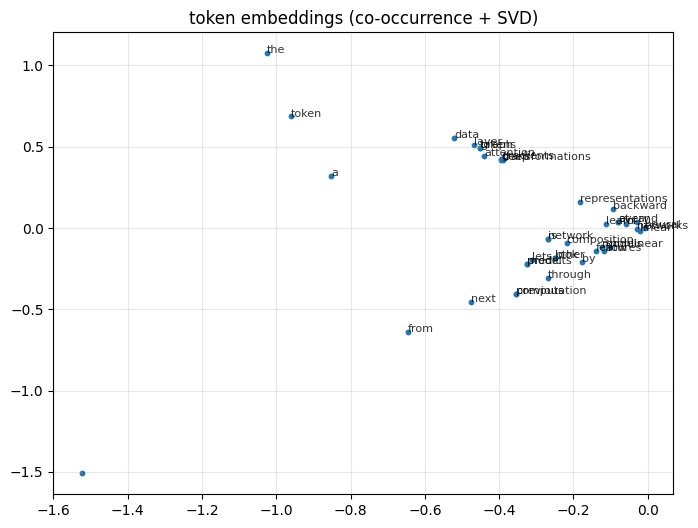

In [4]:
# Build simple co-occurrence embeddings and visualize token relationships with PCA.
vocab = sorted(set(words))
idx = {w: i for i, w in enumerate(vocab)}
V = len(vocab)
co = np.zeros((V, V))
for i in range(len(words) - 1):
    a, b = idx[words[i]], idx[words[i + 1]]
    co[a, b] += 1
    co[b, a] += 1
# PPMI-ish smoothing + SVD for compact embeddings.
co_norm = np.log1p(co)
U, s, _ = np.linalg.svd(co_norm)
emb = U[:, :2] * s[:2]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(emb[:, 0], emb[:, 1], s=10)
for w, (x, y) in zip(vocab, emb, strict=True):
    ax.annotate(w, (x, y), fontsize=8, alpha=0.8)
ax.set_title("token embeddings (co-occurrence + SVD)"); ax.grid(alpha=0.3)
plt.show()

## 3. 次トークン予測 — 事前学習の目標

LLM の事前学習は、ただひとつの目標 **「次のトークンを当てる」** です。

$$
\max \sum_t \log p_\theta(x_{t+1} \mid x_1, \dots, x_t)
$$

膨大なテキストでこれを解くだけで、文法・常識・推論の断片までが副産物として身につきます。
07 章で学習した文字レベル Transformer を再利用し、次トークン分布を確認します。

In [5]:
# Reuse a small char-level transformer (as in ch.07) for next-token prediction.
import torch.nn as nn

block_size = 32
data = torch.tensor(tok.encode(datasets.make_tiny_text_corpus(repeat=40)))


class TinyLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, n_layers=2):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model, n_heads, 4 * d_model, dropout=0.0,
                                       batch_first=True, norm_first=True)
            for _ in range(n_layers)
        ])
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, idx):
        T = idx.shape[1]
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T))
        mask = torch.triu(torch.ones(T, T) * float("-inf"), diagonal=1)
        for blk in self.blocks:
            x = blk(x, src_mask=mask)
        return self.head(self.ln(x))


def get_batch(data, bs=32):
    ix = torch.randint(0, len(data) - block_size - 1, (bs,))
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + 1 + block_size] for i in ix])
    return x, y


set_seed(0)
lm = TinyLM(tok.vocab_size)
opt = torch.optim.Adam(lm.parameters(), lr=3e-3)
for step in range(600):
    x, y = get_batch(data)
    loss = F.cross_entropy(lm(x).reshape(-1, tok.vocab_size), y.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
print(f"final next-token loss: {loss.item():.3f}")

final next-token loss: 0.112


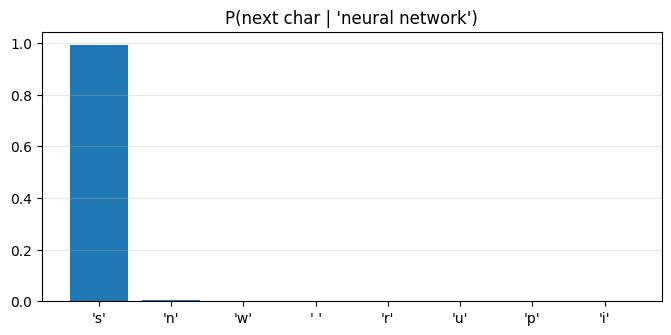

In [6]:
# Next-token probability distribution for a given context.
lm.eval()
ctx = "neural network"
ids = torch.tensor(tok.encode(ctx))[None, -block_size:]
with torch.no_grad():
    probs = F.softmax(lm(ids)[0, -1], dim=-1).numpy()
top = np.argsort(probs)[::-1][:8]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar([repr(tok.itos[i]) for i in top], probs[top])
ax.set_title(f"P(next char | {ctx!r})"); ax.grid(alpha=0.3, axis="y")
plt.show()

## 4. 事前学習からアラインメントへ

事前学習済みモデルは「次トークン予測器」で、必ずしも人間の意図どおりには動きません。
そこで段階的に **アラインメント** します。

| 段階 | 何をするか |
|---|---|
| 事前学習 (pretraining) | 大量テキストで次トークン予測 |
| ファインチューニング | 特定タスク・ドメインのデータで追加学習 |
| 指示チューニング (SFT) | 「指示→応答」ペアで、指示に従う形に |
| RLHF | 人間の好み(報酬モデル)で強化学習し、好まれる応答へ |
| DPO | 報酬モデルを介さず、好み対から直接最適化(RLHF の簡略版) |

**RLHF / DPO の直感** を、玩具の「好みデータ」で示します。
2 つの応答のどちらが好まれるかのペアから、好まれる方の確率を上げます。

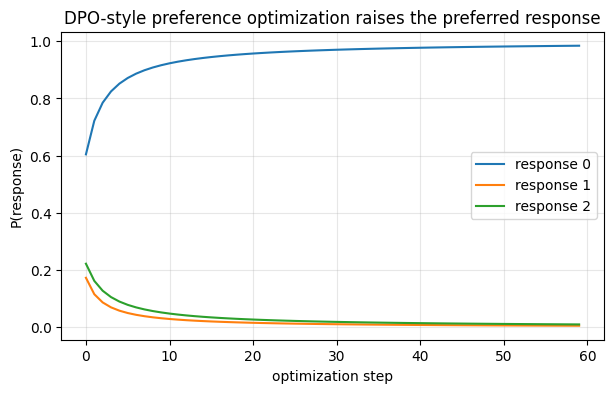

final response probabilities: [0.984 0.006 0.01 ]


In [7]:
# DPO intuition: given preferred vs rejected responses, raise P(preferred).
# Toy setup: 3 candidate "responses" scored by a hidden preference.
torch.manual_seed(0)
n_responses = 3
logits = torch.zeros(n_responses, requires_grad=True)   # model's response preferences
opt = torch.optim.SGD([logits], lr=0.5)

# Human prefers response 0 over 1, and 0 over 2 (pairwise preferences).
pairs = [(0, 1), (0, 2), (0, 1)]
history = []
for step in range(60):
    opt.zero_grad()
    loss = 0.0
    for win, lose in pairs:
        # DPO-style pairwise logistic loss: -log sigmoid(score_win - score_lose).
        loss = loss - F.logsigmoid(logits[win] - logits[lose])
    loss.backward(); opt.step()
    history.append(F.softmax(logits.detach(), 0).numpy())

history = np.array(history)
fig, ax = plt.subplots(figsize=(7, 4))
for r in range(n_responses):
    ax.plot(history[:, r], label=f"response {r}")
ax.set_xlabel("optimization step"); ax.set_ylabel("P(response)")
ax.set_title("DPO-style preference optimization raises the preferred response")
ax.legend(); ax.grid(alpha=0.3)
plt.show()
print("final response probabilities:", history[-1])

好まれた応答 0 の確率が上がりました。
これが RLHF / DPO の核 — **人間の好みでモデルの出力分布を寄せる** という操作です。

## 5. RAG — 検索拡張生成

LLM は学習時点の知識しか持たず、固有情報や最新情報に弱い。
**RAG (Retrieval-Augmented Generation)** は、質問に関連する文書を **検索** して文脈に足し、
その上で生成させます。「外部メモリ付き LLM」です。

最小の検索システム(埋め込み類似度でランキング)を作ります。

In [8]:
# Toy retrieval: rank documents by embedding similarity to a query.
docs = [
    "neural networks learn representations from data",
    "attention lets tokens look at each other",
    "convolution shares weights across an image",
    "gradient descent minimizes the loss function",
    "transformers power modern language models",
]
query = "how do neural language models learn"


def bag_of_words_embed(sentence, vocab_set):
    vec = np.zeros(len(vocab_set))
    for w in sentence.lower().split():
        if w in vocab_set:
            vec[vocab_set[w]] += 1
    return vec


all_words = sorted({w for d in docs + [query] for w in d.lower().split()})
vset = {w: i for i, w in enumerate(all_words)}
doc_vecs = np.array([bag_of_words_embed(d, vset) for d in docs])
q_vec = bag_of_words_embed(query, vset)


def cosine(a, b):
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)


scores = np.array([cosine(q_vec, dv) for dv in doc_vecs])
order = np.argsort(scores)[::-1]
print(f"query: {query!r}\n")
for rank, i in enumerate(order):
    print(f"  rank {rank + 1}: score={scores[i]:.3f}  {docs[i]!r}")

query: 'how do neural language models learn'

  rank 1: score=0.365  'transformers power modern language models'
  rank 2: score=0.333  'neural networks learn representations from data'
  rank 3: score=0.000  'gradient descent minimizes the loss function'
  rank 4: score=0.000  'convolution shares weights across an image'
  rank 5: score=0.000  'attention lets tokens look at each other'


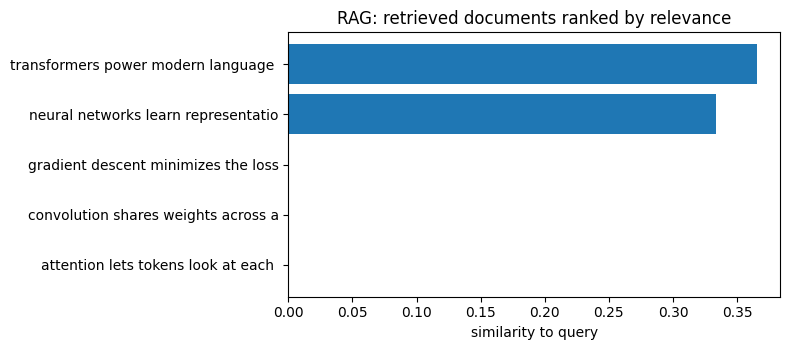


-> the top documents would be prepended to the prompt as context.


In [9]:
# Visualize the retrieval ranking.
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh([docs[i][:35] for i in order[::-1]], scores[order[::-1]])
ax.set_xlabel("similarity to query"); ax.set_title("RAG: retrieved documents ranked by relevance")
plt.tight_layout()
plt.show()
print("\n-> the top documents would be prepended to the prompt as context.")

## 6. LoRA — 低ランク適応で安く微調整

巨大モデルの全パラメータを微調整するのは高価です。
**LoRA (Low-Rank Adaptation)** は、元の重み $W_0$ を凍結し、
低ランクの差分だけを学習します。

$$
W_\text{eff} = W_0 + \frac{\alpha}{r} A B, \qquad A \in \mathbb{R}^{d \times r},\; B \in \mathbb{R}^{r \times k},\; r \ll d, k
$$

学習するのは $A, B$ だけ。パラメータ数が劇的に減ります。
`nn_textbook.models.LoRALinear` で削減量を確認します。

In [10]:
# LoRA adds a tiny low-rank update instead of touching the full weight matrix.
from nn_textbook.models import LoRALinear

rng = np.random.default_rng(0)
W0 = rng.standard_normal((1000, 1000))   # a big frozen weight
print(f"full weight parameters: {W0.size:,}")
for r in [1, 4, 16, 64]:
    lora = LoRALinear(W0, rank=r, alpha=2 * r)
    pct = 100 * lora.n_lora_params() / lora.n_full_params()
    print(f"  rank {r:>3}: LoRA params = {lora.n_lora_params():>7,}  ({pct:.1f}% of full)")

full weight parameters: 1,000,000
  rank   1: LoRA params =   2,000  (0.2% of full)
  rank   4: LoRA params =   8,000  (0.8% of full)
  rank  16: LoRA params =  32,000  (3.2% of full)
  rank  64: LoRA params = 128,000  (12.8% of full)


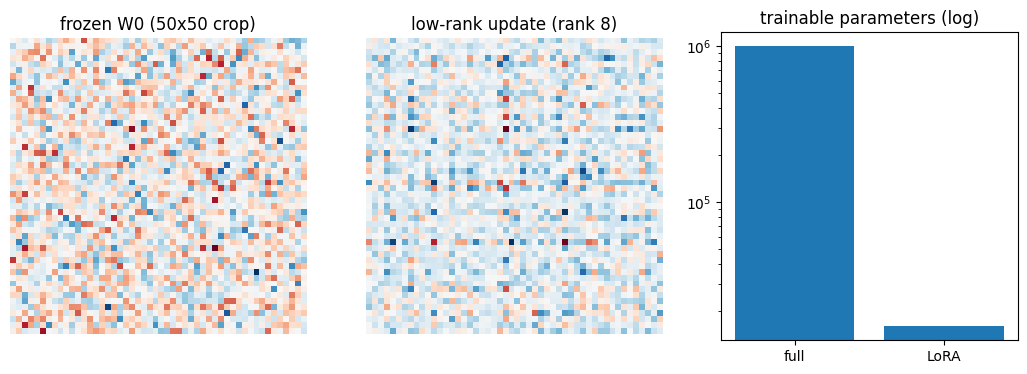

rank of the update matrix: 8


In [11]:
# The low-rank update can still represent a meaningful change to the weights.
lora = LoRALinear(W0, rank=8, alpha=16)
rng = np.random.default_rng(1)
lora.A = rng.standard_normal(lora.A.shape) * 0.1
lora.B = rng.standard_normal(lora.B.shape) * 0.1
delta = lora.effective_weight() - W0

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(W0[:50, :50], cmap="RdBu"); axes[0].set_title("frozen W0 (50x50 crop)")
axes[1].imshow(delta[:50, :50], cmap="RdBu"); axes[1].set_title(f"low-rank update (rank {8})")
axes[2].bar(["full", "LoRA"], [lora.n_full_params(), lora.n_lora_params()])
axes[2].set_yscale("log"); axes[2].set_title("trainable parameters (log)")
for ax in axes[:2]:
    ax.axis("off")
plt.show()
print(f"rank of the update matrix: {np.linalg.matrix_rank(delta)}")

## 7. スケーリング則(高レベル)

経験的に、LLM の損失はモデルサイズ・データ量・計算量に対して **べき乗則** で改善します。

$$
L(N) \approx L_\infty + (N_0 / N)^{\alpha}
$$

($N$ はパラメータ数、$\alpha$ は小さな正の指数)。
「大きく・多く・長く」が予測可能に効く — これが大規模化を後押ししました。
概念図を描きます(実測値ではなく、形を示すための模式)。

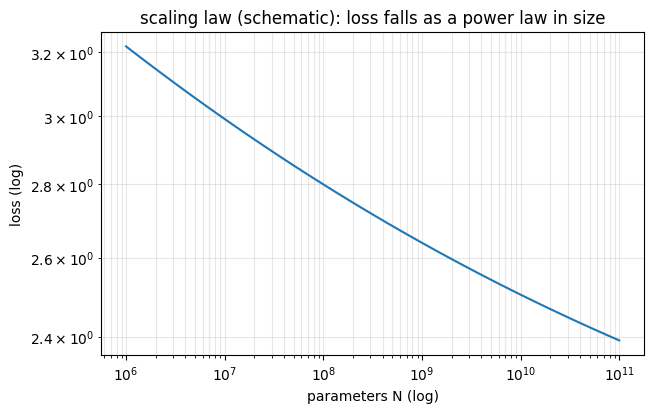

In [12]:
# Illustrative scaling law: loss decreases as a power law in model size.
N = np.logspace(6, 11, 100)           # parameters from 1M to 100B
L = 1.8 + (1e8 / N) ** 0.076          # schematic Chinchilla-like shape
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.loglog(N, L)
ax.set_xlabel("parameters N (log)"); ax.set_ylabel("loss (log)")
ax.set_title("scaling law (schematic): loss falls as a power law in size")
ax.grid(alpha=0.3, which="both")
plt.show()

## 8. 推論の概念

学習済み LLM を使う(推論)ときの主な概念:

- **自己回帰生成**: トークンを 1 個ずつ生成し、出力を入力に足して繰り返す(07 章の generate)
- **温度 / top-k / top-p**: 次トークン分布の鋭さ・候補を制御し、多様性と確実性を調整
- **KV キャッシュ**: 過去トークンの Key/Value を再利用し、生成を高速化
- **コンテキスト長**: 一度に見られるトークン数($O(T^2)$ の注意がボトルネック、07 章)

温度の効果だけ、次トークン分布で見ます。

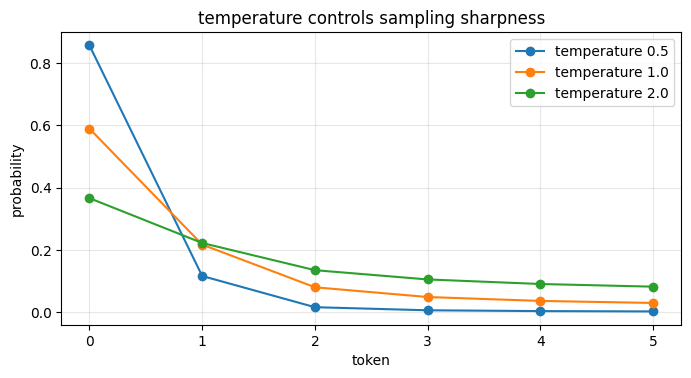

In [13]:
# Temperature reshapes the next-token distribution: low = sharp, high = flat.
logits = np.array([3.0, 2.0, 1.0, 0.5, 0.2, 0.0])
fig, ax = plt.subplots(figsize=(8, 3.8))
for temp in [0.5, 1.0, 2.0]:
    p = softmax_np(logits / temp)
    ax.plot(p, "o-", label=f"temperature {temp}")
ax.set_xlabel("token"); ax.set_ylabel("probability")
ax.set_title("temperature controls sampling sharpness"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 9. Application — 現代 LLM の全体像

本章の概念を組み合わせると、現代の LLM パイプラインになります。

1. **トークナイズ**(BPE)→ テキストを ID 列に
2. **事前学習**: 巨大コーパスで次トークン予測(07 章の Transformer をスケール)
3. **SFT → RLHF/DPO**: 指示に従い、人間に好まれる形へアラインメント
4. **LoRA** などで効率的にドメイン適応
5. **RAG** で外部知識を接続
6. **推論**: 温度・KV キャッシュ・長いコンテキストで実用化

巨大さの裏で動いているのは、この教材で一つずつ作ってきた部品
(線形変換・活性化・逆伝播・注意・埋め込み・次トークン予測)です。

## 10. まとめ

- LLM パイプライン: **トークナイズ → 事前学習(次トークン予測)→ SFT → RLHF/DPO →(LoRA 適応・RAG 接続)→ 推論**。
- 次トークン予測というひとつの目標から、文法・知識・推論の断片が副産物として現れる。
- **DPO** は好みペアの logistic 損失で出力分布を直接寄せる(報酬モデル不要の RLHF 簡略版)。
- **RAG** は検索で外部知識を文脈に注入。**LoRA** は低ランク差分だけ学習(1% 未満のパラメータも可)。
- **スケーリング則** がサイズ・データ・計算の投資対効果を予測可能にした。
- 巨大モデルの中身は、本書で一つずつ作った部品(線形変換・活性化・逆伝播・注意・埋め込み)の合成。

## 11. Exercises

1. 文字レベルと単語レベルのトークナイズで、同じ文の系列長を比べよ。
   部分単語(BPE)が両者の中間である理由を考えよ。
2. RAG の検索を bag-of-words から SVD 埋め込み(本章 §2)に変え、ランキングがどう変わるか見よ。
3. LoRA のランク $r$ を変え、更新行列の表現力(`matrix_rank`)とパラメータ数の関係を調べよ。
4. DPO の好みペアを変え(例: 応答 2 を最良に)、確率分布の収束先がどう動くか確認せよ。
5. 温度 0.1 / 1 / 3 で §3 の言語モデルから生成し、出力の多様性を比較せよ。
6. (発展)スケーリング則の指数 $\alpha$ を変え、損失曲線の傾きがどう変わるか観察せよ。

## 12. Advanced Notes

**なぜ次トークン予測だけで知能的な振る舞いが出るか。** 次トークンを正確に予測するには、
文法・事実・文脈・初歩的な推論まで暗黙にモデル化する必要があります。
十分なデータと容量があれば、これらが「予測の副産物」として現れる、というのが
現在の有力な見方です(emergent abilities の議論)。

**RLHF と DPO の関係。** RLHF は報酬モデルを学習し、PPO 等で方策を最適化する 2 段階。
DPO はこの最適解が好み対の対数尤度で閉じて書けることを利用し、報酬モデルなしで
直接最適化します(本章のロジスティック損失がその核)。実装が単純で安定なため普及しました。

**LoRA がなぜ効くか。** 事前学習済み重みへの「タスク適応」の差分は、しばしば本質的に
低ランク(少数の方向の変化)だと経験的に分かっています。だから低ランク $AB$ で十分捉えられ、
推論時は $W_0 + \frac{\alpha}{r}AB$ をマージすれば追加コストもゼロになります
(姉妹教材 `analytics/linear_algebra` の 05 章「低ランク近似」と地続きの発想)。

**スケーリング則の含意。** Chinchilla(Hoffmann et al. 2022)は、計算予算を
モデルサイズとデータ量に最適配分する法則を示し、「データも一緒に増やすべき」ことを明らかにしました。
スケーリング則は次世代モデルの性能を事前に見積もる実用ツールになっています。

**この教材の到達点。** ここまでで、パーセプトロンから現代 LLM までの主要概念を、
すべて小さな動く実装で辿りました。巨大モデルも、本質は本書で作った部品の合成です。